# Setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import wandb
except ImportError:
    wandb = None
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.data.graph_building import build_graph_features
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import mask_data, preprocess
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.training.loops import train
from src.visualization.training_plots import plot_toxicity_distribution, plot_training
from src.data.splitting import butina_split, generate_scaffold

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


# Load And Filter Data


In [2]:
selected_columns = [
    'SK_unique_id',
    'species_common_name',
    'species_latin_name',
    'CAS',
    'chemical_name',
    'conc_unit',
    'conc',
    'duration',
    'duration_unit',
    'effect',
    'endpoint',
    'SMILES',
    'organism_lifestage_categorized',
    'administration_route_categorized',
    'NCBI_sci_name',
    'NCBI_last_known_rank',
    'NCBI_rank_superkingdom',
    'NCBI_rank_kingdom',
    'NCBI_rank_phylum',
    'NCBI_rank_subphylum',
    'NCBI_rank_class',
    'NCBI_rank_order',
    'NCBI_rank_family',
    'NCBI_rank_genus',
    'NCBI_rank_species',
    'species_group_corrected'
]

df_all = load_data(DATA_PATH, selected_columns)

df_all = df_all.rename(columns={
    'species_group_corrected': 'species_group',
    'organism_lifestage_categorized': 'organism_lifestage',
    'administration_route_categorized': 'administration_route'
})

# Rename columns starting with NCBI_ to be more concise
df_all = df_all.rename(columns={
    'NCBI_rank_superkingdom': 'superkingdom',
    'NCBI_rank_kingdom': 'kingdom',
    'NCBI_rank_phylum': 'phylum',
    'NCBI_rank_subphylum': 'subphylum',
    'NCBI_rank_class': 'class',
    'NCBI_rank_order': 'order',
    'NCBI_rank_family': 'family',
    'NCBI_rank_genus': 'genus',
    'NCBI_rank_species': 'species',
    'NCBI_sci_name': 'species_sci_name',
    'NCBI_last_known_rank': 'taxid'
})

print(df_all['duration'].value_counts())

# Fill missing organimsm_lifestage -> adult, administration_route -> fill, duration_unit -> h
df_all['organism_lifestage'] = df_all['organism_lifestage'].fillna('adult')
df_all['administration_route'] = df_all['administration_route'].fillna('fill')
df_all['duration_unit'] = df_all['duration_unit'].fillna('h')

# Filters
filters = {
    "conc_unit": ["mg/L"],
    "duration_unit": ["h"],
    # "endpoint": ["EC50"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}
require_duration = False
require_taxonomy = True

taxonomy_cols = (
    "class",
    "family",
    "genus",
    "species",
)

# Create mask
mask = mask_data(
    df_all,
    filters=filters,
    require_duration=require_duration,
    require_taxonomy=require_taxonomy,
    taxonomy_columns=taxonomy_cols,
)

# Apply mask and filter
df_filtered = df_all.loc[mask].copy()

# Convert taxonomy columns to numeric, coercing errors to NaN and then to nullable Int64
for col in taxonomy_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors="coerce").astype("Int64")

print()
print("Loaded and filtered training data")
print(f"Rows in full data: {len(df_all):,}")
print(f"Rows after filter: {len(df_filtered):,}")
print()
print("Filtered preview")
print(df_filtered.head())


duration
96.00       64216
48.00       55824
24.00       45443
72.00       30372
168.00      19659
            ...  
219.36          1
510.24          1
301.68          1
51840.00        1
59040.00        1
Name: count, Length: 2309, dtype: int64
Filters
conc_unit: ['mg/L']
True: 0.460
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxonomy: True
True: 0.916

Loaded and filtered training data
Rows in full data: 561,100
Rows after filter: 229,472

Filtered preview
   SK_unique_id species_common_name species_latin_name        CAS  \
25     RTECS225               mouse       Mus musculus    75-07-0   
27     RTECS238                 rat  Rattus norvegicus    75-07-0   
57     RTECS428                 rat  Rattus norvegicus   105-57-7   
80     RTECS490               mouse       Mus musculus  9002-91-9   
81     RTECS491                 rat  Rattus norvegicus  9002-91-9   

                   chemical_name conc_u

# Preprocess Molecules And Targets


In [3]:
# Cut dataset for faster experiments
MAX_ROWS = 50000  # set to an integer like 15000 for faster experiments
# MAX_ROWS = None
random_state = 11

# Optionally limit the number of rows for faster experiments
if MAX_ROWS is not None and len(df_filtered) > MAX_ROWS:
    df_filtered = df_filtered.sample(n=MAX_ROWS, random_state=random_state).reset_index(drop=True)
else:
    df_filtered = df_filtered.reset_index(drop=True)


# Preprocess data
SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0
LOG_TRANSFORM_DURATION = True

df_processed = preprocess(
    df_filtered.copy(),
    split_salts=True,
    remove_lone=False,
    remove_metals=False,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

print(f"Rows before preprocessing: {len(df_filtered):,}")
print(f"Rows after preprocessing:  {len(df_processed):,}")
print(f"Rows removed: {len(df_filtered) - len(df_processed):,}")
print()
print("Preprocessed preview")
print(df_processed[["SMILES", "duration_raw", "duration", "conc", "log10c"]].head())
print()
print_mol_types(df_processed)


[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:36] WARNING: not removing hydrogen atom without neighbors
[21:45:37] WARNING: not removing hydrogen atom without neighbors
[21:45:37] WARNING: not r

Rows before preprocessing: 50,000
Rows after preprocessing:  49,404
Rows removed: 596

Preprocessed preview
                                  SMILES  duration_raw  duration     conc  \
0  CCCOCC(=Nc1ccc(Cl)cc1C(F)(F)F)n1ccnc1          72.0  1.857332    1.000   
1                               CC(C)CCN          48.0  1.681241  385.000   
2                 COC(=O)c1ccccc1C(=O)OC          72.0  1.857332  115.000   
3                      O=C([O-])C(F)(F)F          72.0  1.857332    0.620   
4                                 [NH4+]          96.0  1.982271    0.399   

     log10c  
0  0.000000  
1  2.585461  
2  2.060698  
3 -0.207608  
4 -0.399027  

Total molecules: 49404
Unique molecules: 5472
Disconnected species: 0, 0.00%
Single-node species: 6743, 13.65%
Metals: 10136, 20.52%


# Encoding Data

## Featiruze molecules

In [4]:
from src.data.featurization import simple_featurizer

# df_processed["features"] = df_processed["SMILES"].apply(from_smiles)

# atom_features = ["atomic_num", "mass"]
# bond_features = ["bond_order"]
df_processed["features"] = df_processed["SMILES"].apply(simple_featurizer)

sample_id = min(16, len(df_processed) - 1)

print()
print(f"{len(df_processed):,} rows with graph features created")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'


Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'
[21:45:48] WARNING: not removing hydrogen atom without neighbors
[21:45:50] WARNING: not removing hydrogen atom without neighbors



49,404 rows with graph features created


## Taxonomy Encoding

In [5]:
USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = "../Data/moredata/pretrained_tax_emb.pkl.zip"

tax_embedding = {
    "taxid": 16,
    # "genus": 8,
    # "family": 8,
    # "class": 4,
}

model_tax_embedding = (
    {key: value for key, value in tax_embedding.items() if key != "taxid"}
    if USE_PRETRAINED_TAXID
    else tax_embedding
)

df_tax = df_processed[list(tax_embedding.keys())].copy()
df_tax, encoders = sequential_encoder(df_tax, tax_embedding.keys())
# df_tax now contains only the sequential data for selected columns

config_tax = build_config(df_tax, model_tax_embedding)
taxid_decoder = {encoded: original for original, encoded in encoders["taxid"].items()}
taxid_lookup = (
    df_processed[["taxid", "species_sci_name"]]
    .dropna(subset=["taxid", "species_sci_name"])
    .drop_duplicates(subset=["taxid"])
    .set_index("taxid")["species_sci_name"]
    .to_dict()
)


if not USE_PRETRAINED_TAXID:
    print("Don't use pretrained taxid embeddings")
    print("Taxonomy embedding config")
    print(config_tax)


if USE_PRETRAINED_TAXID:
    print(f"Use pretrained taxid embeddings")
    print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

Use pretrained taxid embeddings
Pretrained taxid path: ../Data/moredata/pretrained_tax_emb.pkl.zip


## Categorical and Numerical Encoding

In [6]:
# Add some more metadata cols
df_processed["fragment_count"] = df_processed["SMILES"].apply(fragment_count).astype(float)
df_processed["is_salt"] = df_processed["SMILES"].apply(is_salt).astype(float)
df_processed["has_metal"] = df_processed["SMILES"].apply(has_metal).astype(float)
df_processed["is_single_node"] = df_processed["SMILES"].apply(is_single_node).astype(float)

# Categorical encoding
categorical_cols = [
    "endpoint", 
    "effect", 
    "is_salt",
    "has_metal",
    "is_single_node"
    ]

df_categorical = df_processed[categorical_cols].copy()
df_categorical, categorical_encoders = sequential_encoder(df_categorical, categorical_cols)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, categorical_cols)

print("Categorical embedding config:")
print(config_categorical)
print()

# Numerical encoding 
numerical_cols = [
    "duration",
    "fragment_count",
    # "is_salt",
    # "has_metal",
    # "is_single_node",
]

print("Numerical encoding for:")
print(numerical_cols)


Categorical embedding config:
{'endpoint': 4, 'effect': 9, 'is_salt': 1, 'has_metal': 2, 'is_single_node': 2}

Numerical encoding for:
['duration', 'fragment_count']


# Build The Final Graph Dataset


In [7]:
features = build_graph_features(
    df_processed, 
    df_tax, 
    tax_embedding, 
    df_categorical,
    categorical_cols,
    numerical_cols
    )

sample_feature = features[sample_id]

print(f"Graph objects created: {len(features):,}")
print()
print("Info for a sample:")
print(features[sample_id])


Graph objects created: 49,404

Info for a sample:
Data(x=[12, 7], edge_index=[2, 24], edge_attr=[24, 3], smiles='Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1Cl', y=-0.33724215626716614, row_id=16, taxid=15, taxid_raw=176853, endpoint=1, effect=3, is_salt=0, has_metal=0, is_single_node=0, duration=2.225309371948242, fragment_count=1.0)


# Prepare for training

## Split data

In [8]:
split_method = "butina"
frac_train = 0.7
frac_valid = 0.1
frac_test = 0.2
cluster_csv_path = "../Data/moredata/original/butina_cluster_lookup.csv"

train_dataset, test_dataset, val_dataset = butina_split(
    features,
    frac_train=frac_train,
    frac_test=frac_test,
    frac_valid=frac_valid,
    cluster_csv_path=cluster_csv_path,
    cluster_column="Cluster_at_cutoff_0.3",
)

train_targets_before = np.array([g.y.item() for g in train_dataset])
val_targets_before = np.array([g.y.item() for g in val_dataset])
test_targets_before = np.array([g.y.item() for g in test_dataset])
train_smiles = [g.smiles for g in train_dataset]
val_smiles = [g.smiles for g in val_dataset]
test_smiles = [g.smiles for g in test_dataset]

print(f"Split method: {split_method}")
print(f"Train size: {len(train_dataset):,} ({len(train_dataset) / len(features):.1%})")
print(f"Val size:   {len(val_dataset):,} ({len(val_dataset) / len(features):.1%})")
print(f"Test size:  {len(test_dataset):,} ({len(test_dataset) / len(features):.1%})")
print()
print(f"Unique molecules in train: {len(set(train_smiles)):,}")
print(f"Unique molecules in val:   {len(set(val_smiles)):,}")
print(f"Unique molecules in test:  {len(set(test_smiles)):,}")
print(f"Val molecules not in train:  {len(set(val_smiles) - set(train_smiles)):,}")
print(f"Test molecules not in train: {len(set(test_smiles) - set(train_smiles)):,}")
print()
print("Target distribution before normalization")
print(f"Train mean/std: {train_targets_before.mean():.4f} / {train_targets_before.std():.4f}")
print(f"Val mean/std:   {val_targets_before.mean():.4f} / {val_targets_before.std():.4f}")
print(f"Test mean/std:  {test_targets_before.mean():.4f} / {test_targets_before.std():.4f}")


Using csv file
Split method: butina
Train size: 34,583 (70.0%)
Val size:   4,941 (10.0%)
Test size:  9,880 (20.0%)

Unique molecules in train: 500
Unique molecules in val:   449
Unique molecules in test:  4,523
Val molecules not in train:  449
Test molecules not in train: 4,523

Target distribution before normalization
Train mean/std: -0.2321 / 1.7991
Val mean/std:   0.3081 / 1.7741
Test mean/std:  0.6721 / 1.5032


## Normalize The Target


Mean used: -0.2321
Std used:  1.7991

Target distribution after normalization
Train mean/std: 0.0000 / 1.0000
Val mean/std:   0.3003 / 0.9861
Test mean/std:  0.5026 / 0.8355


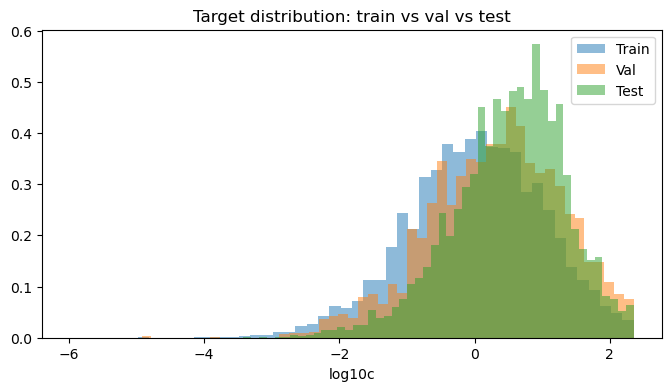

In [9]:
target_mean = train_targets_before.mean()
target_std = train_targets_before.std()

for dataset in (train_dataset, val_dataset, test_dataset):
    for g in dataset:
        g.y = (g.y - target_mean) / target_std

train_targets_after = np.array([g.y.item() for g in train_dataset])
val_targets_after = np.array([g.y.item() for g in val_dataset])
test_targets_after = np.array([g.y.item() for g in test_dataset])

print(f"Mean used: {target_mean:.4f}")
print(f"Std used:  {target_std:.4f}")
print()
print("Target distribution after normalization")
print(f"Train mean/std: {train_targets_after.mean():.4f} / {train_targets_after.std():.4f}")
print(f"Val mean/std:   {val_targets_after.mean():.4f} / {val_targets_after.std():.4f}")
print(f"Test mean/std:  {test_targets_after.mean():.4f} / {test_targets_after.std():.4f}")

plot_toxicity_distribution(train_dataset, test_dataset, val_dataset=val_dataset)


## Build DataLoaders


In [10]:
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

first_batch = next(iter(train_loader))

print(f"Batch size: {batch_size}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print()
print("First batch summary")
print(f"Graphs in batch: {first_batch.num_graphs}")
print(f"x shape: {tuple(first_batch.x.shape)}")
print(f"edge_index shape: {tuple(first_batch.edge_index.shape)}")
print(f"edge_attr shape: {tuple(first_batch.edge_attr.shape)}")
print(f"y shape: {tuple(first_batch.y.shape)}")


Batch size: 256
Train batches per epoch: 136
Val batches: 20
Test batches: 39

First batch summary
Graphs in batch: 256
x shape: (3103, 7)
edge_index shape: (2, 6162)
edge_attr shape: (6162, 3)
y shape: (256,)


# Model and training


## Build model

In [11]:
from src.models.attentive_fp import AttentiveFP
from src.models.afp_flex import AFPFlex
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder, TaxonomyEncoder, TaxonomyOneHot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TAX_DIM = 32
PRETRAINED_TAXID_OUTPUT_DIM = 32
CATEGORICAL_DIM = 16
NUMERIC_DIM = 16
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 64
GNN_OUT_DIM = 64

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.4

FINAL_HIDDEN_DIM = 64

ATOM_FEATURE_DIM = features[0].x.shape[1]
EDGE_FEATURE_DIM = features[0].edge_attr.shape[1]

meta_encoder = MetaEncoder(
    taxonomy_encoder_cls=TaxonomyOneHot,
    config_tax=config_tax,
    tax_output_dim=TAX_DIM,
    pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
    pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
    config_categorical=config_categorical,
    categorical_output_dim=CATEGORICAL_DIM,
    numerical_columns=numerical_cols,
    numeric_output_dim=NUMERIC_DIM,
    dropout=META_DROPOUT
).to(device)


model_gnn = AFPFlex(
    in_channels=ATOM_FEATURE_DIM,
    edge_dim=EDGE_FEATURE_DIM,
    hidden_channels=GNN_HIDDEN_DIM,
    out_channels=GNN_OUT_DIM,
    num_layers=NUM_LAYERS,
    num_timesteps=NUM_TIMESTEPS,
    dropout=DROPOUT,
).to(device)

model = ToxicityModel(
    model_gnn,
    meta_encoder,
    hidden_dim=FINAL_HIDDEN_DIM,
).to(device)

n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad)
n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad)
n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"Device: {device}")
print(f"Meta encoder trainable parameters: {n_params_meta:,}")
print(f"GNN trainable parameters: {n_params_gnn:,}")
print(f"Total trainable parameters: {n_params_total:,}")
print()
print(model)


Device: cpu
Meta encoder trainable parameters: 617,088
GNN trainable parameters: 130,112
Total trainable parameters: 755,649

ToxicityModel(
  (gnn): AFPFlex(
    (lin1): Linear(in_features=7, out_features=64, bias=True)
    (gate_conv): GATEConv()
    (gru): GRUCell(64, 64)
    (atom_convs): ModuleList(
      (0-1): 2 x GATConv(64, 64, heads=1)
    )
    (atom_grus): ModuleList(
      (0-1): 2 x GRUCell(64, 64)
    )
    (mol_conv): GATConv(64, 64, heads=1)
    (mol_gru): GRUCell(64, 64)
    (linlone): Linear(in_features=64, out_features=64, bias=True)
    (lin2): Linear(in_features=64, out_features=64, bias=True)
  )
  (meta_encoder): MetaEncoder(
    (categorical_encoder): CategoricalOneHot(
      (projection): Sequential(
        (0): Linear(in_features=18, out_features=16, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.3, inplace=False)
      )
    )
    (numeric_encoder): NumericalEncoder(
      (projection): Sequential(
        (0): Linear(in_features=2, out_features=16

## Train The Model


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vollmers/.netrc.
wandb: Currently logged in as: elonvg (elonvg-chalmers-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training configuration
epochs = 100
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
early_stopping_patience = 30


Epoch 54/100:  53%|█████▎    | 53/100 [08:24<07:26,  9.51s/epoch, train_loss=0.2828, val_loss=0.4698, val_rmse=0.8844, val_mae=0.6736, test_loss=0.4641, test_rmse=0.8662, test_mae=0.6725, lr=7.50e-05]

Early stopping at epoch 53: no improvement in val_loss for 30 epochs.


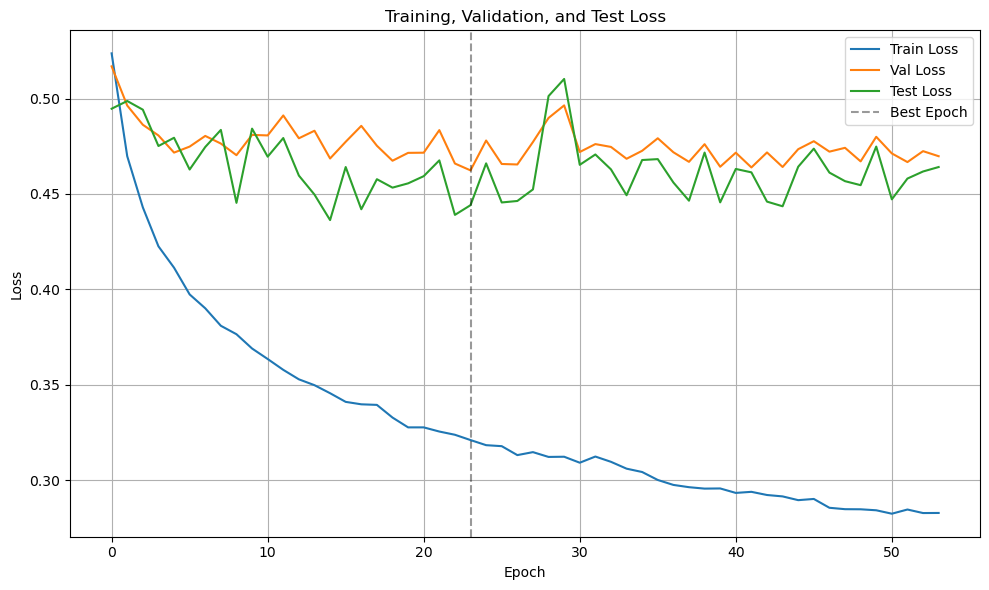

In [12]:
epochs = 100
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5
early_stopping_patience = 30
early_stopping_min_delta = 1e-4

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

USE_WANDB = wandb is not None  # set to False to skip tracking
wandb_run = None

wandb.init(
    project="gnn-thesis",
    entity="elonvg-chalmers-university-of-technology",
)

if USE_WANDB:
    wandb_run = wandb.init(
        project="gnn-thesis",
        job_type="train",
        tags=["notebook", split_method, type(model_gnn).__name__],
        config={
            "random_state": random_state,
            "n_samples": MAX_ROWS,

            "filters": filters,
            "split_salt": SPLIT_SALTS,
            "remove_lone": REMOVE_LONE,
            "remove_metals": REMOVE_METALS,
            "max_conc_value": MAX_CONC_VALUE,
            "duration_fill_value": DURATION_FILL_VALUE,
            "max_duration_hours": MAX_DURATION_HOURS,
            "log_transform_duration": LOG_TRANSFORM_DURATION,

            "num_atom_features": ATOM_FEATURE_DIM,
            "num_bond_features": EDGE_FEATURE_DIM,

            "tax_embedding": tax_embedding,
            "use_pretrained_taxid": USE_PRETRAINED_TAXID,
            "categorical_cols": categorical_cols,
            "numerical_cols": numerical_cols,

            "split_method": split_method,
            "frac_train": frac_train,
            "frac_valid": frac_valid,
            "frac_test": frac_test,
            "target_mean": float(target_mean),
            "target_std": float(target_std),

            "batch_size": batch_size,
            "taxonomy_encoder": TaxonomyOneHot.__name__,
            "gnn_model": type(model_gnn).__name__,
            "tax_dim": TAX_DIM,
            "pretrained_taxid_output_dim": PRETRAINED_TAXID_OUTPUT_DIM,
            "categorical_dim": CATEGORICAL_DIM,
            "numeric_dim": NUMERIC_DIM,
            "meta_dropout": META_DROPOUT,
            "gnn_hidden_dim": GNN_HIDDEN_DIM,
            "gnn_out_dim": GNN_OUT_DIM,
            "num_layers": NUM_LAYERS,
            "num_timesteps": NUM_TIMESTEPS,
            "dropout": DROPOUT,
            "final_hidden_dim": FINAL_HIDDEN_DIM,
            "n_params_meta": n_params_meta,
            "n_params_gnn": n_params_gnn,
            "n_params_total": n_params_total,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "loss": loss_fn.__class__.__name__,
            "loss_beta": loss_beta,
            "early_stopping_patience": early_stopping_patience,
            "early_stopping_min_delta": early_stopping_min_delta,
        },
    )
    wandb_run.define_metric("epoch")
    for metric_prefix in ("train/*", "val/*", "test/*", "optimizer/*"):
        wandb_run.define_metric(metric_prefix, step_metric="epoch")
else:
    print("wandb not installed; running without experiment tracking.")

print("Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")
print(f"early_stopping_patience = {early_stopping_patience}")

model_trained, history = train(
    model,
    train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    run=wandb_run,
)

model = model_trained
plot_training(history)


# Results

## Check Overall Test Performance

In [ ]:
from src.training.loops import predict_df
from src.visualization.result_plots import summarize_by_group, plot_group_mae

analysis_df = df_processed.reset_index(drop=True)[[
    "species_group",
    "species_sci_name",
    "endpoint",
    "effect",
    "fragment_count",
    "has_metal",
    "is_single_node",
]].copy()
analysis_df = analysis_df.rename(columns={"species_sci_name": "species_latin_name"})
analysis_df["fragment_bin"] = pd.cut(analysis_df["fragment_count"], [-1, 1, 2, np.inf], labels=["1", "2", "3+"])
analysis_df["has_metal_group"] = analysis_df["has_metal"].map({0.0: "No metal", 1.0: "Has metal"})
analysis_df["is_single_group"] = analysis_df["is_single_node"].map({0.0: "Not single-node", 1.0: "Single-node"})

results_df = predict_df(model, test_loader, device, cols=["row_id", "smiles", "taxid_raw"])
results_df["row_id"] = results_df["row_id"].astype(int)
results_df["taxid"] = results_df["taxid_raw"].astype(int)
results_df = results_df.drop(columns="taxid_raw").join(analysis_df, on="row_id")

results_df["pred_log10c"] = results_df["pred_norm"] * target_std + target_mean
results_df["actual_log10c"] = results_df["actual_norm"] * target_std + target_mean
results_df["residual_log10c"] = results_df["pred_log10c"] - results_df["actual_log10c"]
results_df["abs_error_log10c"] = results_df["residual_log10c"].abs()
results_df["pred_conc"] = 10 ** results_df["pred_log10c"]
results_df["actual_conc"] = 10 ** results_df["actual_log10c"]
results_df["fold_error"] = np.maximum(
    results_df["pred_conc"] / results_df["actual_conc"],
    results_df["actual_conc"] / results_df["pred_conc"],
)

train_df = analysis_df.iloc[[g.row_id.item() for g in train_dataset]].copy()

summary_metrics = {
    "test/r2_norm": r2_score(results_df["actual_norm"], results_df["pred_norm"]),
    "test/r2_log10c": r2_score(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/rmse_log10c": mean_squared_error(results_df["actual_log10c"], results_df["pred_log10c"]) ** 0.5,
    "test/mae_log10c": mean_absolute_error(results_df["actual_log10c"], results_df["pred_log10c"]),
    "test/median_fold_error": results_df["fold_error"].median(),
}

print("Overall test-set metrics")
print(f"R^2 (normalized target): {summary_metrics['test/r2_norm']:.3f}")
print(f"R^2 (log10c): {summary_metrics['test/r2_log10c']:.3f}")
print(f"RMSE (log10c): {summary_metrics['test/rmse_log10c']:.3f}")
print(f"MAE (log10c): {summary_metrics['test/mae_log10c']:.3f}")
print(f"Median fold error (conc scale): {summary_metrics['test/median_fold_error']:.3f}")

if wandb_run is not None:
    wandb_run.summary.update(summary_metrics)

    predictions_for_wandb = results_df[[
        "row_id",
        "smiles",
        "taxid",
        "species_latin_name",
        "species_group",
        "endpoint",
        "effect",
        "fragment_bin",
        "has_metal_group",
        "is_single_group",
        "actual_norm",
        "pred_norm",
        "actual_log10c",
        "pred_log10c",
        "residual_log10c",
        "abs_error_log10c",
        "fold_error",
    ]].copy()
    predictions_for_wandb["fragment_bin"] = predictions_for_wandb["fragment_bin"].astype(str)
    wandb_run.log({"predictions/test": wandb.Table(dataframe=predictions_for_wandb)})

largest_errors = results_df[[
    "species_latin_name",
    "species_group",
    "endpoint",
    "effect",
    "actual_log10c",
    "pred_log10c",
    "abs_error_log10c",
    "fold_error",
    "smiles",
]].sort_values("abs_error_log10c", ascending=False).head(10)

largest_errors


Overall test-set metrics
R^2 (normalized target): -0.001
R^2 (log10c): -0.001
RMSE (log10c): 1.504
MAE (log10c): 1.173
Median fold error (conc scale): 9.095


,species_latin_name,species_group,endpoint,effect,actual_log10c,pred_log10c,abs_error_log10c,fold_error,smiles
1078,varroa destructor,insects,EC50,MOR,-5.826814,1.990293,7.817106,6.563060e+07,CC1(C)C(C=CC(=O)OC(C(F)(F)F)C(F)(F)F)C1C(=O)OC(C#N)c1cccc(Oc2ccccc2)c1
6158,raoiella indica,insects,EC50,MOR,-5.397940,2.217971,7.615911,4.129626e+07,CC1=CCC2CC(CC3(CCC(C)C(C)O3)O2)OC(=O)C2C=C(C)C(O)C3OCC(=CC=CC(C)C1)C23O
3404,drosophila melanogaster,insects,EC50,REP,-3.173925,3.465326,6.639252,4.357642e+06,C=C(Cl)CCl
3843,cyprinus carpio,fish,EC50,MOR,-5.045757,1.402641,6.448399,2.808010e+06,O=[N+]([O-])c1ccc([N+](=O)[O-])cc1
8440,drosophila melanogaster,insects,EC50,REP,-2.886057,3.162650,6.048707,1.118682e+06,BrCC1CO1
1046,ictalurus furcatus,fish,LOEC,POP,2.301030,-3.566359,5.867389,7.368664e+05,CC12CCC3C(CCC4CC(=O)CCC43C)C1CCC2O
1044,ictalurus furcatus,fish,LOEC,POP,2.301030,-3.566359,5.867389,7.368664e+05,CC12CCC3C(CCC4CC(=O)CCC43C)C1CCC2O
6202,varroa destructor,insects,EC50,MOR,-3.600257,2.089304,5.689561,4.892844e+05,Cc1ccc(N=CN(C)C=Nc2ccc(C)cc2C)c(C)c1
7238,thanatephorus cucumeris,fungi,EC50,POP,-4.397940,1.190545,5.588486,3.876908e+05,Cc1nn(C)c(F)c1C(=O)Nc1ccccc1C(C)CC(C)C
2244,rattus norvegicus,rodents,LOEC,GRO,-4.522879,1.022854,5.545732,3.513440e+05,CCC1(O)CC2CN(CCc3c([nH]c4ccccc34)C(C(=O)OC)(c3cc4c(cc3OC)N(C=O)C3C(O)(C(=O)O...


wandb: WARNING Artifact "run-aypsi847-predictionstest-uPizrA" already exists with the same content. No new version will be created.


## Visual Result Checks

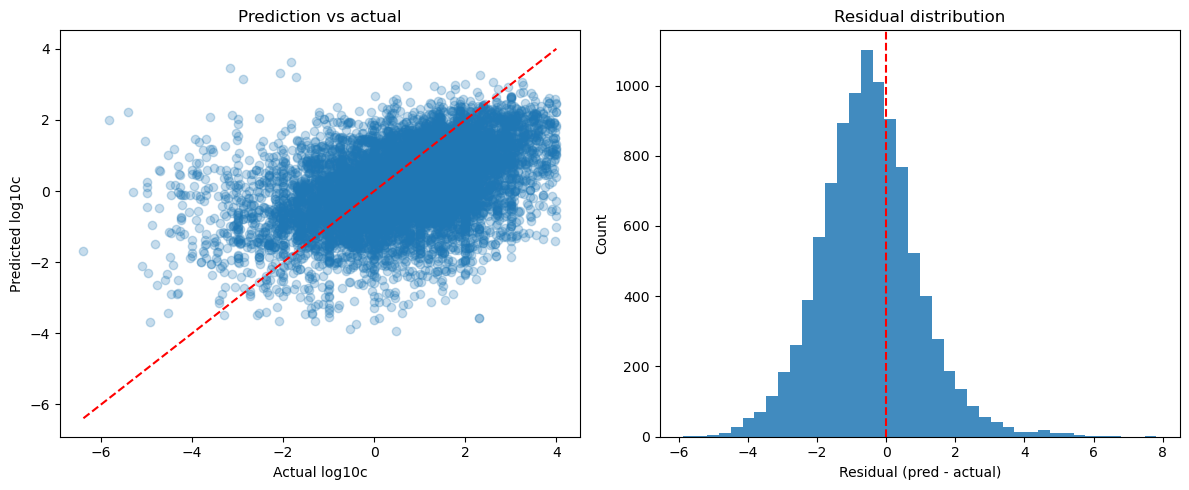

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["actual_log10c"], results_df["pred_log10c"], alpha=0.25)
plot_min = min(results_df["actual_log10c"].min(), results_df["pred_log10c"].min())
plot_max = max(results_df["actual_log10c"].max(), results_df["pred_log10c"].max())
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[0].set_xlabel("Actual log10c")
axes[0].set_ylabel("Predicted log10c")
axes[0].set_title("Prediction vs actual")

axes[1].hist(results_df["residual_log10c"], bins=40, alpha=0.85)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()


## Performance By Group

In [ ]:
group_cols = [
    "species_group",
    "endpoint",
    "effect",
    "fragment_bin",
    "has_metal_group",
]

group_summaries = {}
for group_col in group_cols:
    title = group_col.replace("_", " ").title()
    summary = summarize_by_group(results_df, train_df, group_col, min_count=25)
    group_summaries[group_col] = summary

    print(title)
    display(summary[["group", "n", "model_mae", "baseline_mae", "mae_gain"]])
    plot_group_mae(summary, title=f"{title}: model vs train subgroup mean")

species_summary = summarize_by_group(results_df, train_df, "species_latin_name", min_count=20)
print("Top species with at least 20 test rows")
display(species_summary.head(15)[["group", "n", "model_mae", "baseline_mae", "mae_gain"]])

print("Single-node support on the test set")
print(results_df["is_single_group"].value_counts(dropna=False).to_string())

if wandb_run is not None:
    for group_col, summary in group_summaries.items():
        wandb_run.log({f"group_summary/{group_col}": wandb.Table(dataframe=summary)})
    wandb_run.log({"group_summary/species_latin_name": wandb.Table(dataframe=species_summary)})
    wandb_run.finish()


KeyError: 'Column not found: log10c'